# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [1]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.

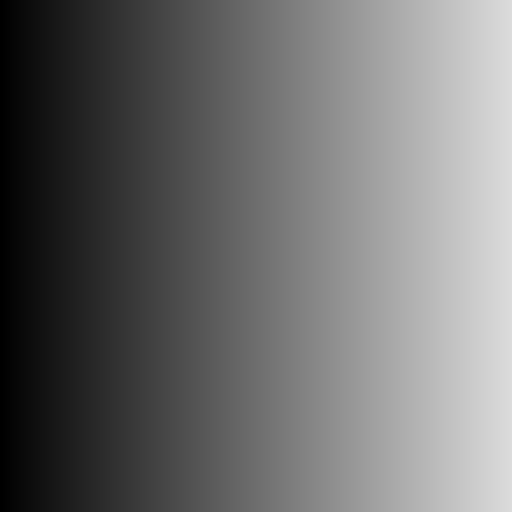

In [12]:

alto = 512
ancho = 512
gradiente = np.tile(np.linspace(0, 220, ancho, dtype=np.uint8), (alto, 1))
imagen = cv2.merge([gradiente, gradiente, gradiente])
cv2_imshow(imagen)
imageio.imwrite("gradiente.png", imagen)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).

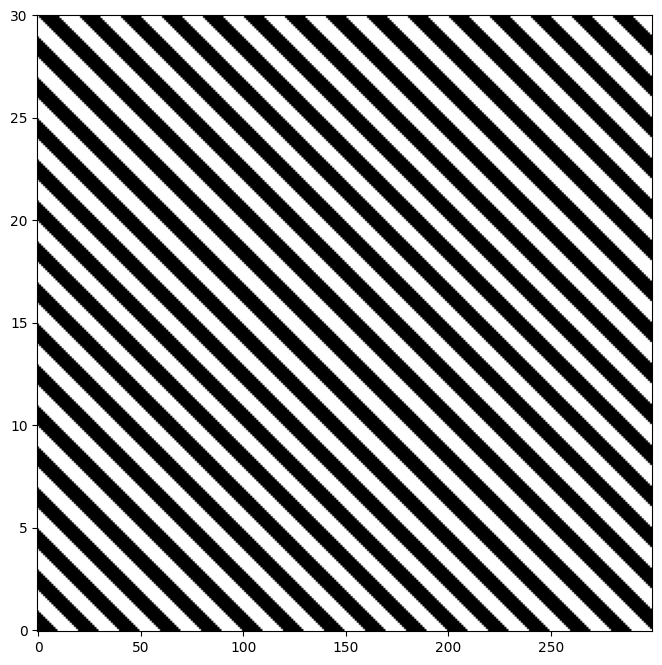

In [24]:

alto = 300
ancho = 300

y, x = np.indices((alto, ancho))

espesor = 10

patron = ((x + y) // espesor) % 2

imagen = (patron * 255).astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(imagen, cmap='gray', origin='upper')


labels = np.arange(0, 31, 5)
posiciones = labels * (ancho / 30)

plt.yticks(posiciones, labels)

plt.gca().invert_yaxis()
plt.show()

imageio.imwrite("lineas_diagonales.png", imagen)

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

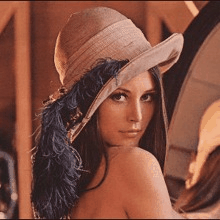

In [42]:

img1 = cv2.imread('/content/1.jpeg')
img2 = cv2.imread('/content/tigre.jpg')

img1 = img1[:,:,::-1]
img2 = img2[:,:,::-1]


h, w, c = img1.shape
img2 = cv2.resize(img2, (w,h))


img1 = img1.astype(np.float32)
img2 = img2.astype(np.float32)

frames = []


num_frames = 30


for i in range(num_frames):

    alpha = i/(num_frames-1)


    frame = (1-alpha)*img1 + alpha*img2

    frame = np.clip(frame,0,255).astype(np.uint8)

    frames.append(frame)

# Guardar GIF
imageio.mimsave('/content/resultado.gif', frames, duration=0.07)

from IPython.display import Image
Image(filename='/content/resultado.gif')


### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).

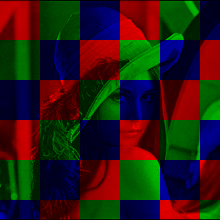

In [31]:

img = cv2.imread('/content/1.jpeg')

resultado = img.copy()

bloque = 40

alto, ancho, canales = resultado.shape


for y in range(0, alto, bloque):
    for x in range(0, ancho, bloque):

        bloque_img = resultado[y:y+bloque, x:x+bloque]


        selector = ((x // bloque) + (y // bloque)) % 3

        if selector == 0:
            # Rojo
            bloque_img[:,:,0] = 0
            bloque_img[:,:,1] = 0

        elif selector == 1:
            # Verde
            bloque_img[:,:,0] = 0
            bloque_img[:,:,2] = 0

        else:
            # Azul
            bloque_img[:,:,1] = 0
            bloque_img[:,:,2] = 0

        resultado[y:y+bloque, x:x+bloque] = bloque_img
cv2_imshow(resultado)

### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

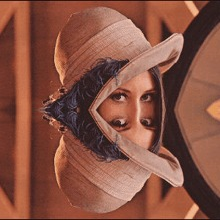

In [45]:

import warnings
warnings.filterwarnings("ignore")
# Cargar imagen
img = imageio.imread('/content/1.jpeg')

# Convertir a formato OpenCV
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# Dimensiones
h, w, c = img.shape

# Mitad superior
top = img[0:h//2, :, :]

# Reflejo vertical
mirror = cv2.flip(top, 0)

# Unir ambas partes
result = np.vstack((top, mirror))

# Mostrar solo el resultado
cv2_imshow(result)